In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers




## Dataset
Bock, R. (2004). MAGIC Gamma Telescope [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52C8B.

In [28]:
pd.read_csv('magic04.data', header=None)

,0,1,2,3,4,5,6,7,8,9,10
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
...,...,...,...,...,...,...,...,...,...,...,...
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


#### Data info and processing
    1.  fLength:  continuous  # major axis of ellipse [mm]
    2.  fWidth:   continuous  # minor axis of ellipse [mm] 
    3.  fSize:    continuous  # 10-log of sum of content of all pixels [in #phot]
    4.  fConc:    continuous  # ratio of sum of two highest pixels over fSize  [ratio]
    5.  fConc1:   continuous  # ratio of highest pixel over fSize  [ratio]
    6.  fAsym:    continuous  # distance from highest pixel to center, projected onto major axis [mm]
    7.  fM3Long:  continuous  # 3rd root of third moment along major axis  [mm] 
    8.  fM3Trans: continuous  # 3rd root of third moment along minor axis  [mm]
    9.  fAlpha:   continuous  # angle of major axis with vector to origin [deg]
    10.  fDist:    continuous  # distance from origin to center of ellipse [mm]
    11.  class:    g,h         # gamma (signal), hadron (background)

In [29]:
cols = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
df =pd.read_csv('magic04.data', names=cols)

In [30]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [31]:
df['class'].value_counts()

,count
class,
g,12332
h,6688


In [32]:
df['class'] = df['class'].map({'g': 1, 'h': 0})
# df['class'] = (df['class'] == 'g').astype(int)

In [33]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


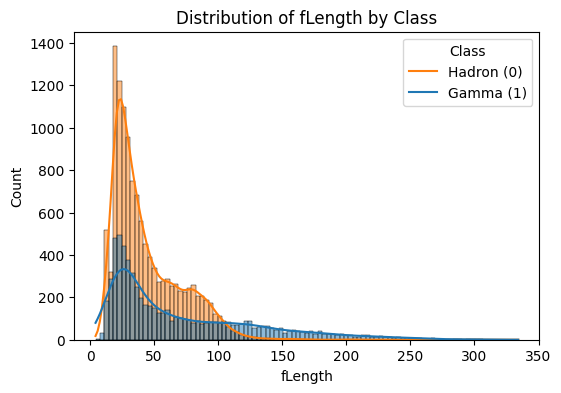

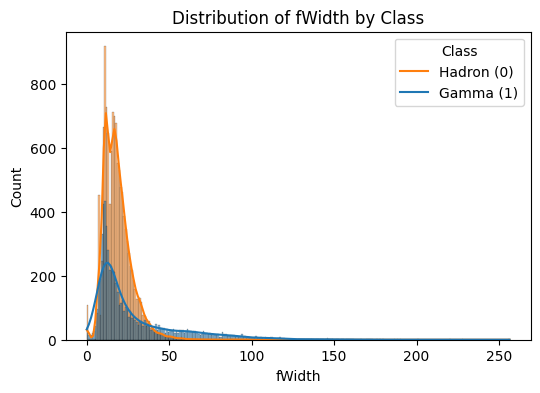

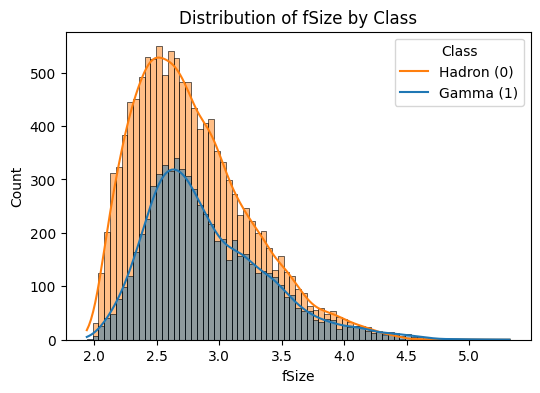

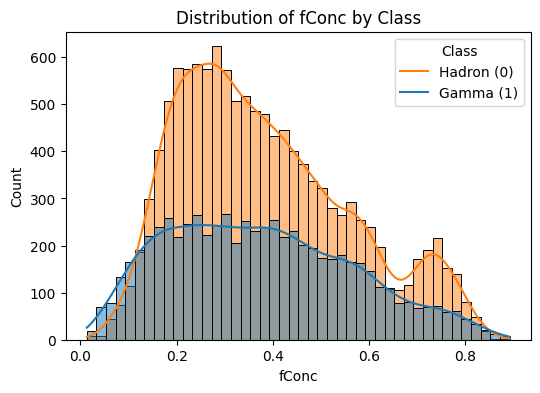

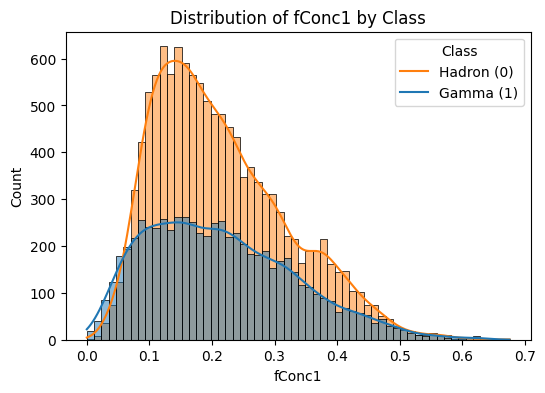

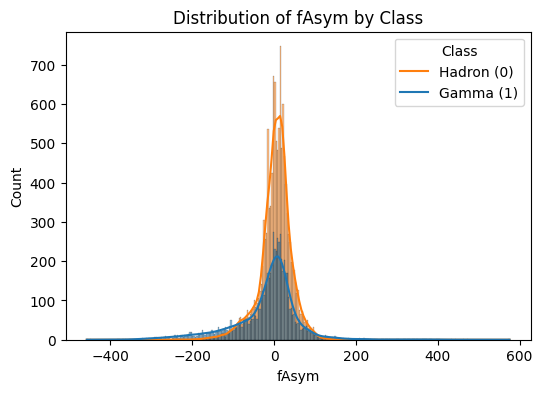

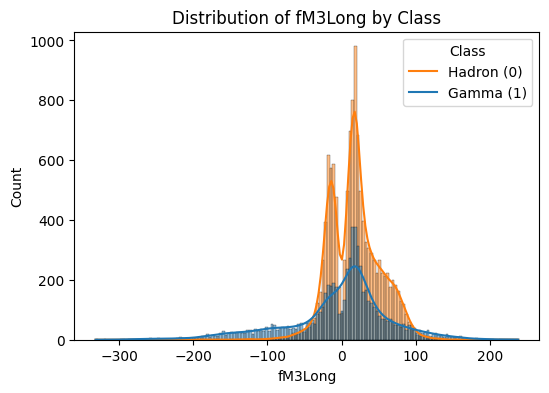

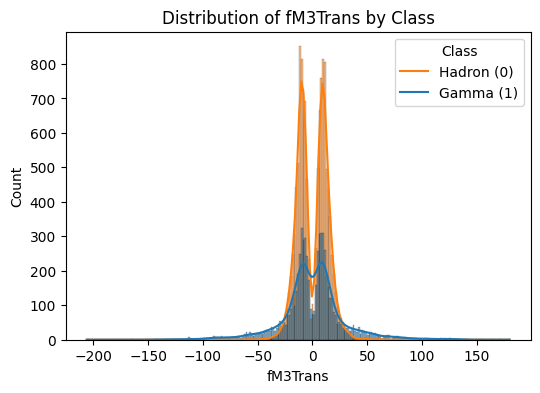

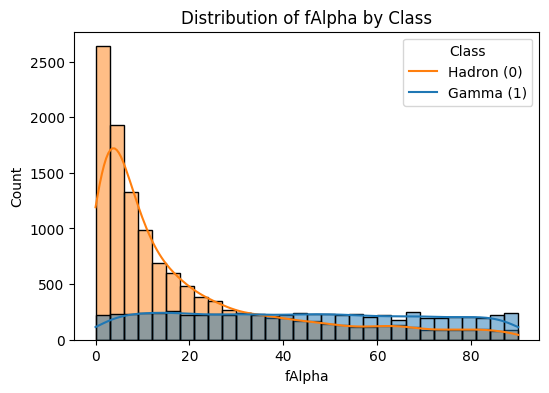

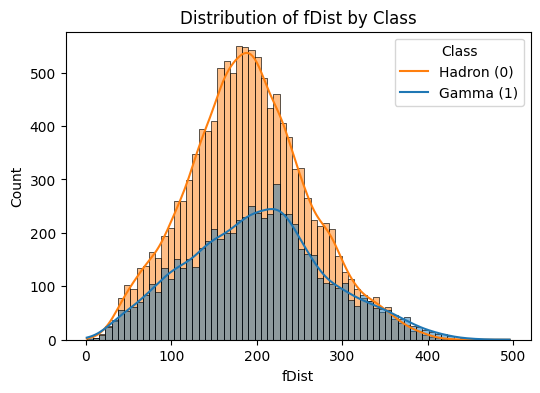

In [34]:
for label in df.columns[:-1]:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=label, hue='class', kde=True, stat='count', common_norm=False,hue_order=[0, 1])
    plt.title(f'Distribution of {label} by Class')
    plt.xlabel(label)
    plt.ylabel('Count')
    plt.legend(title='Class', labels=['Hadron (0)', 'Gamma (1)'])
    plt.show()

# Train, validation, test datasets

In [35]:
train,validation,test = np.split(df.sample(frac=1, random_state=42).to_numpy(), [int(0.7*len(df)), int(0.85*len(df))])

In [36]:
def scale_features(df, over_sample=False):
    X = df[:,:10]
    y = df[:,10]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    if over_sample:
        ROS = RandomOverSampler(random_state=42)
        X_scaled, y = ROS.fit_resample(X_scaled, y)

    data = np.hstack((X_scaled, y.reshape(-1, 1)))
    
    return data,X_scaled,y

    

In [37]:
print(train.shape)


(13314, 11)


In [38]:
train

array([[ 48.0573,  11.0862,   2.9571, ...,  26.93  , 165.224 ,   0.    ],
       [ 23.4858,   0.    ,   2.2393, ...,  19.341 , 235.342 ,   1.    ],
       [ 40.5429,  19.4073,   3.3382, ...,  10.0643, 195.603 ,   1.    ],
       ...,
       [ 23.0476,  16.8067,   2.4819, ...,   0.8687, 251.14  ,   0.    ],
       [ 21.1123,  15.8118,   2.5198, ...,  75.2845, 216.205 ,   1.    ],
       [ 25.7545,   7.7716,   2.3032, ...,   7.3793, 153.144 ,   1.    ]])

In [39]:
print(len(train[train[:, 10] == 1]))
print(len(train[train[:, 10] == 0]))

# print(len(train[train.iloc[:, 10] == 1]))
# print(len(train[train.iloc[:, 10] == 0]))

8650
4664


In [40]:
train,X_train,y_train = scale_features(train, over_sample=True)
validation,X_val,y_val = scale_features(validation)
test,X_test,y_test = scale_features(test)

In [41]:
print(sum(y_train == 1))

print(sum(y_train == 0))

8650
8650


# KNN

In [42]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [43]:
y_pred = knn.predict(X_test)

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.73      0.74      0.74       991
         1.0       0.86      0.86      0.86      1862

    accuracy                           0.82      2853
   macro avg       0.80      0.80      0.80      2853
weighted avg       0.82      0.82      0.82      2853



## Naive Bayes

In [45]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [46]:
y_pred = nb_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.65      0.40      0.49       991
         1.0       0.73      0.89      0.80      1862

    accuracy                           0.72      2853
   macro avg       0.69      0.64      0.65      2853
weighted avg       0.71      0.72      0.70      2853



## Logistic Regression


In [47]:
lg_model = LogisticRegression()
lg_model.fit(X_train, y_train)

LogisticRegression()

In [48]:
y_pred = lg_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.68      0.71      0.69       991
         1.0       0.84      0.82      0.83      1862

    accuracy                           0.78      2853
   macro avg       0.76      0.77      0.76      2853
weighted avg       0.79      0.78      0.78      2853



## Suport Vector Machines(SVM)

In [49]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

SVC()

In [50]:
y_pred = svm_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.79      0.79      0.79       991
         1.0       0.89      0.89      0.89      1862

    accuracy                           0.86      2853
   macro avg       0.84      0.84      0.84      2853
weighted avg       0.86      0.86      0.86      2853



## Neural Networks

In [54]:
print(X_train.shape)

(17300, 10)


In [ ]:
nn_model = keras.Sequential([
   keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])